In [7]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/mahirprojects/customer-churn-input/churn_model_input.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

In [8]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

text_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
             'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
             'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in text_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'])
df = df.drop(columns=['customerID'])

In [9]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1033
           1       0.60      0.61      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407



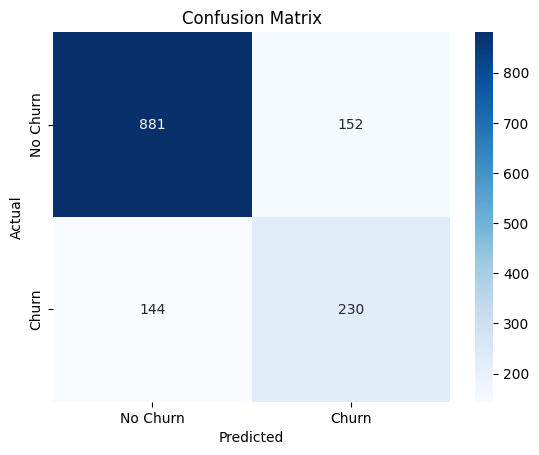

In [10]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

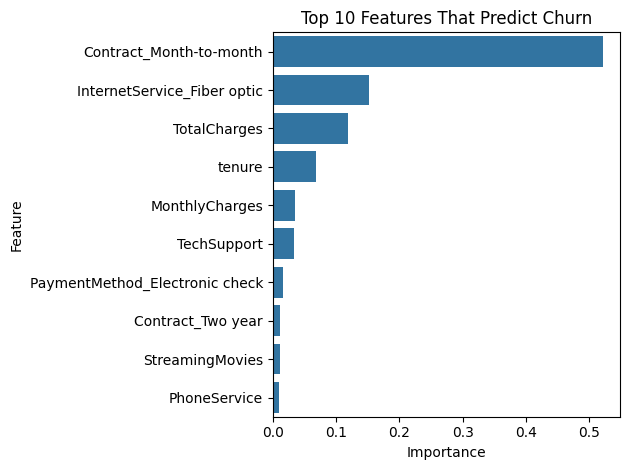

                           Feature  Importance
19         Contract_Month-to-month    0.522339
17     InternetService_Fiber optic    0.151209
15                    TotalCharges    0.119405
4                           tenure    0.069048
14                  MonthlyCharges    0.035825
10                     TechSupport    0.033303
24  PaymentMethod_Electronic check    0.015660
21               Contract_Two year    0.011837
12                 StreamingMovies    0.010663
5                     PhoneService    0.009507


In [11]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Top 10 Features That Predict Churn')
plt.tight_layout()
plt.show()

print(importance_df)